In [1]:
!pip install -q google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd
import time, random

APPS = [
    ('com.gojek.app',          'Gojek'),
    ('com.tokopedia.tkpd',     'Tokopedia'),
    ('com.shopee.id',          'Shopee'),
    ('id.dana.mobile',         'DANA'),
    ('com.bukalapak.android',  'Bukalapak'),
    ('com.ovo.id',             'OVO'),
    ('com.grab.grabmerchant',  'Grab'),
    ('id.co.lazada.mobileapp', 'Lazada'),
]

all_reviews = []

for app_id, app_name in APPS:
    print(f"[SCRAPING] {app_name}")
    for sort_order in [Sort.NEWEST, Sort.MOST_RELEVANT]:
        try:
            result, _ = reviews(app_id, lang='id', country='id',
                                sort=sort_order, count=2000)
            for r in result:
                all_reviews.append({
                    'app':    app_name,
                    'review': r['content'],
                    'score':  r['score'],
                    'date':   str(r['at']),
                })
            print(f"  ✓ {sort_order} → {len(result):,}")
            time.sleep(random.uniform(1, 3))
        except Exception as e:
            print(f"  ✗ {e}")
            time.sleep(3)

df_raw = pd.DataFrame(all_reviews)
df_raw.drop_duplicates(subset=['review'], inplace=True)
df_raw = df_raw[df_raw['review'].str.strip() != ''].reset_index(drop=True)
df_raw.to_csv('dataset.csv', index=False)
print(f"\n✅ {len(df_raw):,} ulasan tersimpan")

[SCRAPING] Gojek
  ✓ Sort.NEWEST → 2,000
  ✓ Sort.MOST_RELEVANT → 2,000
[SCRAPING] Tokopedia
  ✓ Sort.NEWEST → 2,000
  ✓ Sort.MOST_RELEVANT → 2,000
[SCRAPING] Shopee
  ✓ Sort.NEWEST → 2,000
  ✓ Sort.MOST_RELEVANT → 2,000
[SCRAPING] DANA
  ✓ Sort.NEWEST → 0
  ✓ Sort.MOST_RELEVANT → 0
[SCRAPING] Bukalapak
  ✓ Sort.NEWEST → 2,000
  ✓ Sort.MOST_RELEVANT → 2,000
[SCRAPING] OVO
  ✓ Sort.NEWEST → 0
  ✓ Sort.MOST_RELEVANT → 0
[SCRAPING] Grab
  ✓ Sort.NEWEST → 0
  ✓ Sort.MOST_RELEVANT → 0
[SCRAPING] Lazada
  ✓ Sort.NEWEST → 0
  ✓ Sort.MOST_RELEVANT → 0

✅ 13,836 ulasan tersimpan


In [3]:
import pandas as pd
import numpy as np
import re, string, pickle, warnings
import matplotlib.pyplot as plt
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-05-11 06:26:19.775921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778480779.995263      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778480780.057286      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778480780.588993      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778480780.589035      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778480780.589038      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
df = pd.read_csv('/kaggle/input/datasets/michaelsugiarto/dataset/dataset.csv')
df.dropna(subset=['review'], inplace=True)
df.drop_duplicates(subset=['review'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Lexicon kata positif & negatif bahasa Indonesia
POSITIVE_WORDS = set("""
bagus baik mantap keren hebat luar biasa memuaskan puas senang suka
cepat mudah lancar aman nyaman recommended rekomendasi terbaik top
canggih praktis membantu berguna bermanfaat sukses berhasil sempurna
andalan terpercaya terjamin stabil responsif ramah profesional murah
terjangkau cashback promo untung menguntungkan menarik lengkap update
gratis bonus oke ok sip jos gokil kece bintang lima love terima kasih
terimakasih makasih thanks helpful worth cepet gampang ringan smooth
""".split())

NEGATIVE_WORDS = set("""
buruk jelek parah lambat lemot error bug crash gagal tidak bisa
mengecewakan kecewa susah sulit ribet masalah kendala gangguan rusak
bohong tipu penipuan scam hilang hangus pending gagal bayar tidak
respon lambat lama loading lag freeze force close keluar sendiri
boros batere panas overheat iklan spam mengganggu memaksa paksa
zonk percuma sia sia menyebalkan menyusahkan merugikan rugi mahal
sembarangan asal tidak jelas tidak berguna payah ampas sampah
hapus uninstall kapok jera trauma tidak recommended
""".split())

def label_sentiment_text(text):
    text_lower = str(text).lower()
    
    # Hitung kemunculan kata positif dan negatif
    pos_count = sum(1 for word in POSITIVE_WORDS if word in text_lower)
    neg_count = sum(1 for word in NEGATIVE_WORDS if word in text_lower)
    
    if pos_count > neg_count:
        return 'positif'
    elif neg_count > pos_count:
        return 'negatif'
    else:
        return 'netral'

df['sentiment'] = df['review'].apply(label_sentiment_text)

print(f"Total: {len(df):,}")
print(f"\nDistribusi Sentimen:")
print(df['sentiment'].value_counts())
print(f"\nPersentase:")
print((df['sentiment'].value_counts(normalize=True) * 100).round(2))

# Cek sample hasil labeling
print("\n--- Sample Hasil Labeling ---")
for sent in ['positif', 'negatif', 'netral']:
    sample = df[df['sentiment'] == sent]['review'].iloc[0]
    print(f"\n[{sent.upper()}] {sample[:100]}")

Total: 13,768

Distribusi Sentimen:
sentiment
negatif    6408
positif    4453
netral     2907
Name: count, dtype: int64

Persentase:
sentiment
negatif    46.54
positif    32.34
netral     21.11
Name: proportion, dtype: float64

--- Sample Hasil Labeling ---

[POSITIF] karya terbaik bangsa, very helpfull map. Pesan saya, sejahterakan mitra, inshaallah barokah dan maki

[NEGATIF] Tolong jangan Pake Apk ini kalau pesan paket, saya sebagai pembeli sangat kesulitan jika ada driver 

[NETRAL] good


In [5]:
STOPWORDS = set("""
yang dan di ke dari ini itu ada dengan untuk juga sudah saya kita
tidak bisa lebih aja sih dong lah yg ga gak gk tdk udah udh gue gw
lu deh nya kalau kalo banget blm belum sama mereka kami anda bagi
oleh karena seperti serta atau tapi jadi akan pun sedang masih
banyak hanya mau saja sangat sekali kan nih mana harus kok oh ya
nah pake pakai emang memang pernah biasa coba
""".split())

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')  # hapus emoji
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(words)

df['clean_text'] = df['review'].apply(preprocess)
df = df[df['clean_text'].str.strip().str.len() > 3].reset_index(drop=True)

print(f"Setelah preprocessing: {len(df):,}")
df[['review', 'clean_text', 'sentiment']].head(5)

Setelah preprocessing: 13,686


,review,clean_text,sentiment
0,"karya terbaik bangsa, very helpfull map. Pesan...",karya terbaik bangsa very helpfull map pesan s...,positif
1,BANYAK PROMONYA🤧,promonya,positif
2,Driver cepat datangnya dan sampai di tujuan de...,driver cepat datangnya sampai tujuan aman,positif
3,"Tolong jangan Pake Apk ini kalau pesan paket, ...",tolong jangan apk pesan paket sebagai pembeli ...,negatif
4,mantap,mantap,positif


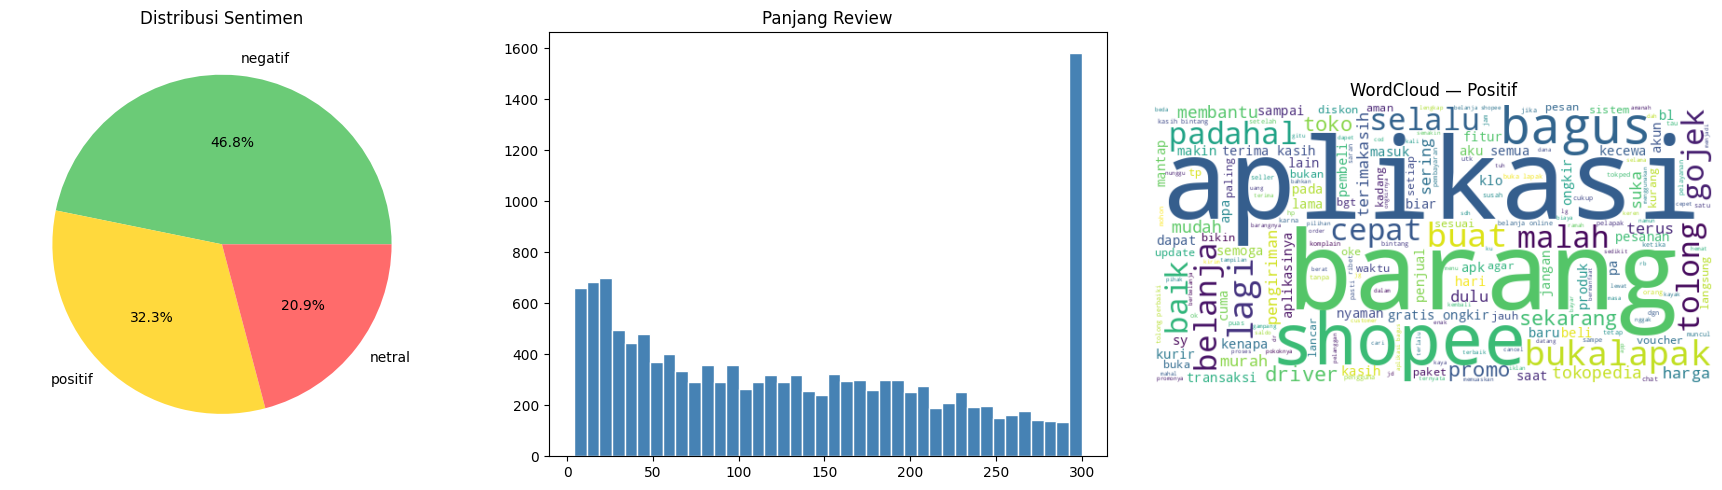

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi
sc = df['sentiment'].value_counts()
axes[0].pie(sc.values, labels=sc.index, autopct='%1.1f%%',
            colors=['#6bcb77','#ffd93d','#ff6b6b'])
axes[0].set_title('Distribusi Sentimen')

# Panjang review
df['rev_len'] = df['clean_text'].apply(len)
axes[1].hist(df['rev_len'].clip(upper=300), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Panjang Review')

# WordCloud
corpus = ' '.join(df[df['sentiment'] == 'positif']['clean_text'])
wc = WordCloud(width=600, height=300, background_color='white').generate(corpus)
axes[2].imshow(wc, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('WordCloud — Positif')

plt.tight_layout()
plt.show()

In [7]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder()
le.fit(['negatif', 'netral', 'positif'])
df['label'] = le.transform(df['sentiment'])

X = df['clean_text'].values
y = df['label'].values

MAX_VOCAB, MAX_LEN, EMBED_DIM = 15000, 80, 64

print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(f"Distribusi sebelum oversample:\n{pd.Series(y).value_counts()}")

# Oversample untuk SVM & RF (hanya teks, bukan pad sequence)
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(pd.DataFrame(X, columns=['text']), y)
X_ros = X_ros['text'].values

print(f"\nDistribusi setelah oversample:\n{pd.Series(y_ros).value_counts()}")

Mapping: {np.str_('negatif'): np.int64(0), np.str_('netral'): np.int64(1), np.str_('positif'): np.int64(2)}
Distribusi sebelum oversample:
0    6405
2    4423
1    2858
Name: count, dtype: int64

Distribusi setelah oversample:
2    6405
0    6405
1    6405
Name: count, dtype: int64


SKEMA 1 — BiLSTM | Split 80/20
Epoch 1/40


I0000 00:00:1778480811.172254      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778480811.178289      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


217/217 ━━━━━━━━━━━━━━━━━━━━ 196s 825ms/step - accuracy: 0.3765 - loss: 1.0815 - val_accuracy: 0.5767 - val_loss: 0.8987
Epoch 2/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 172s 794ms/step - accuracy: 0.6245 - loss: 0.8403 - val_accuracy: 0.7250 - val_loss: 0.7000
Epoch 3/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 169s 777ms/step - accuracy: 0.7476 - loss: 0.6442 - val_accuracy: 0.7666 - val_loss: 0.6125
Epoch 4/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 167s 770ms/step - accuracy: 0.8047 - loss: 0.5301 - val_accuracy: 0.7939 - val_loss: 0.5514
Epoch 5/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 167s 769ms/step - accuracy: 0.8370 - loss: 0.4463 - val_accuracy: 0.8127 - val_loss: 0.5309
Epoch 6/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 168s 774ms/step - accuracy: 0.8671 - loss: 0.3781 - val_accuracy: 0.8205 - val_loss: 0.5137
Epoch 7/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 167s 771ms/step - accuracy: 0.8918 - loss: 0.3098 - val_accuracy: 0.8296 - val_loss: 0.5010
Epoch 8/40
217/217 ━━━━━━━━━━━━━━━━━━━━ 169s 777ms/step - accuracy: 0.9083 - loss: 0.27

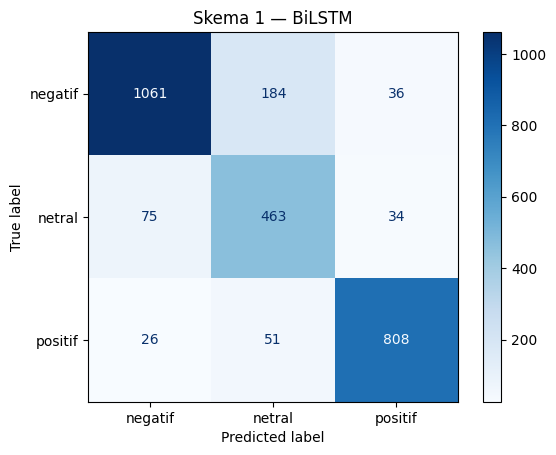

✅ Skema 1 tersimpan.


In [8]:
print("SKEMA 1 — BiLSTM | Split 80/20")

tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tok.fit_on_texts(X_ros)

X_pad_ros  = pad_sequences(tok.texts_to_sequences(X_ros), maxlen=MAX_LEN, padding='post', truncating='post')
X_pad_orig = pad_sequences(tok.texts_to_sequences(X),     maxlen=MAX_LEN, padding='post', truncating='post')

X_tr1, _, y_tr1, _ = train_test_split(X_pad_ros,  y_ros, test_size=0.2, random_state=42, stratify=y_ros)
_, X_te1, _, y_te1 = train_test_split(X_pad_orig, y,     test_size=0.2, random_state=42, stratify=y)

model1 = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=True)),
    Bidirectional(LSTM(64,  dropout=0.3, recurrent_dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax'),
])
model1.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history1 = model1.fit(
    X_tr1, y_tr1,
    epochs=40, batch_size=64, validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1,
)

train_acc1 = model1.evaluate(X_tr1, y_tr1, verbose=0)[1]
test_acc1  = model1.evaluate(X_te1, y_te1, verbose=0)[1]
y_pred1    = np.argmax(model1.predict(X_te1, verbose=0), axis=1)

print(f"\n📊 Train: {train_acc1*100:.2f}% | Test: {test_acc1*100:.2f}%")
print(classification_report(y_te1, y_pred1, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_te1, y_pred1), display_labels=le.classes_).plot(cmap='Blues')
plt.title('Skema 1 — BiLSTM'); plt.show()

model1.save('model_bilstm.h5')
with open('tokenizer_bilstm.pkl', 'wb') as f: pickle.dump(tok, f)
print("✅ Skema 1 tersimpan.")

SKEMA 2 — SVM | Split 80/20
Train: 15,372 | Test: 2,738

📊 Train: 96.95% | Test: 85.43%
              precision    recall  f1-score   support

     negatif       0.93      0.82      0.87      1281
      netral       0.68      0.83      0.75       572
     positif       0.89      0.93      0.91       885

    accuracy                           0.85      2738
   macro avg       0.83      0.86      0.84      2738
weighted avg       0.87      0.85      0.86      2738



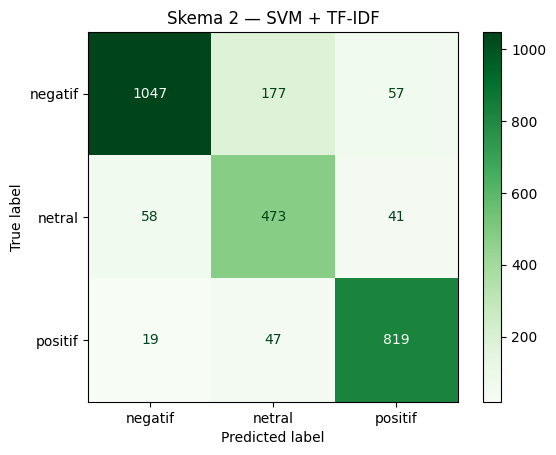

✅ Skema 2 tersimpan.


In [13]:
print("SKEMA 2 — SVM | Split 80/20")

tfidf2 = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.95)

# Pakai X_ros (oversampled) untuk training
X_tfidf2_ros = tfidf2.fit_transform(X_ros)

X_tr2, _, y_tr2, _ = train_test_split(
    X_tfidf2_ros, y_ros, test_size=0.2, random_state=42, stratify=y_ros)

# Test dari data ASLI
_, X_te2, _, y_te2 = train_test_split(
    tfidf2.transform(X), y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(y_tr2):,} | Test: {len(y_te2):,}")

svm = LinearSVC(C=0.5, max_iter=5000, class_weight='balanced', random_state=42)
svm.fit(X_tr2, y_tr2)

train_acc2 = accuracy_score(y_tr2, svm.predict(X_tr2))
y_pred2    = svm.predict(X_te2)
test_acc2  = accuracy_score(y_te2, y_pred2)

print(f"\n📊 Train: {train_acc2*100:.2f}% | Test: {test_acc2*100:.2f}%")
print(classification_report(y_te2, y_pred2, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_te2, y_pred2), display_labels=le.classes_).plot(cmap='Greens')
plt.title('Skema 2 — SVM + TF-IDF'); plt.show()

with open('model_svm.pkl',  'wb') as f: pickle.dump(svm,    f)
with open('tfidf_svm.pkl',  'wb') as f: pickle.dump(tfidf2, f)
print("✅ Skema 2 tersimpan.")

SKEMA 3 — Logistic Regression | Split 70/30
Train: 13,450 | Test: 4,106

📊 Train: 98.43% | Test: 86.75%
              precision    recall  f1-score   support

     negatif       0.94      0.83      0.88      1922
      netral       0.69      0.86      0.77       857
     positif       0.91      0.93      0.92      1327

    accuracy                           0.87      4106
   macro avg       0.85      0.87      0.86      4106
weighted avg       0.88      0.87      0.87      4106



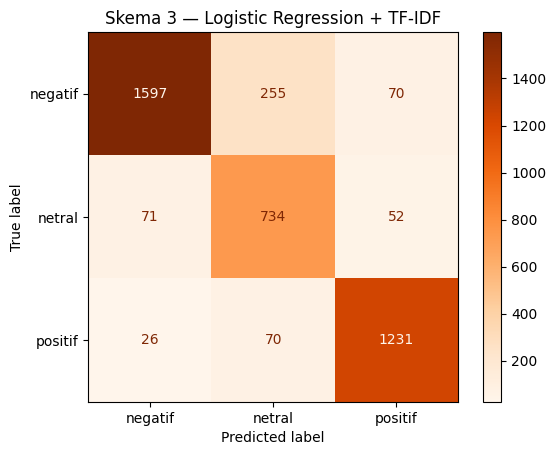

✅ Skema 3 tersimpan.


In [10]:
from sklearn.linear_model import LogisticRegression

print("SKEMA 3 — Logistic Regression | Split 70/30")

tfidf3 = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.95)

X_tfidf3_ros = tfidf3.fit_transform(X_ros)

X_tr3, _, y_tr3, _ = train_test_split(
    X_tfidf3_ros, y_ros, test_size=0.3, random_state=42, stratify=y_ros)

_, X_te3, _, y_te3 = train_test_split(
    tfidf3.transform(X), y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(y_tr3):,} | Test: {len(y_te3):,}")

lr = LogisticRegression(C=5.0,           # naik dari 1.0 → lebih ekspresif
                         max_iter=2000,
                         class_weight='balanced',
                         solver='lbfgs',  # lebih stabil dari saga
                         n_jobs=-1,
                         random_state=42)
lr.fit(X_tr3, y_tr3)

train_acc3 = accuracy_score(y_tr3, lr.predict(X_tr3))
y_pred3    = lr.predict(X_te3)
test_acc3  = accuracy_score(y_te3, y_pred3)

print(f"\n📊 Train: {train_acc3*100:.2f}% | Test: {test_acc3*100:.2f}%")
print(classification_report(y_te3, y_pred3, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_te3, y_pred3), display_labels=le.classes_).plot(cmap='Oranges')
plt.title('Skema 3 — Logistic Regression + TF-IDF'); plt.show()

with open('model_lr.pkl',  'wb') as f: pickle.dump(lr,     f)
with open('tfidf_lr.pkl',  'wb') as f: pickle.dump(tfidf3, f)
print("✅ Skema 3 tersimpan.")

  Skema           Algoritma           Fitur Split Train Acc Test Acc
Skema 1              BiLSTM Keras Embedding 80/20    92.92%   85.17%
Skema 2                 SVM  TF-IDF 1-2gram 80/20    96.95%   85.43%
Skema 3 Logistic Regression  TF-IDF 1-2gram 70/30    98.43%   86.75%


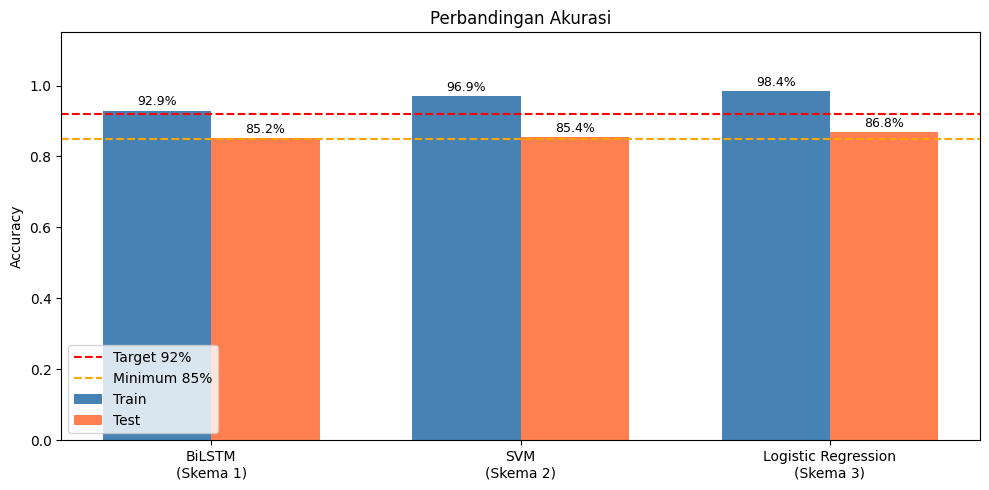

In [14]:
summary = pd.DataFrame({
    'Skema':     ['Skema 1', 'Skema 2', 'Skema 3'],
    'Algoritma': ['BiLSTM', 'SVM', 'Logistic Regression'],
    'Fitur':     ['Keras Embedding', 'TF-IDF 1-2gram', 'TF-IDF 1-2gram'],
    'Split':     ['80/20', '80/20', '70/30'],
    'Train Acc': [f'{train_acc1*100:.2f}%', f'{train_acc2*100:.2f}%', f'{train_acc3*100:.2f}%'],
    'Test Acc':  [f'{test_acc1*100:.2f}%',  f'{test_acc2*100:.2f}%',  f'{test_acc3*100:.2f}%'],
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.35
b1 = ax.bar(x-w/2, [train_acc1, train_acc2, train_acc3], w, label='Train', color='steelblue')
b2 = ax.bar(x+w/2, [test_acc1,  test_acc2,  test_acc3],  w, label='Test',  color='coral')
for b in [*b1, *b2]:
    ax.annotate(f'{b.get_height()*100:.1f}%',
                xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,4), textcoords='offset points', ha='center', fontsize=9)
ax.axhline(0.92, color='red',    linestyle='--', label='Target 92%')
ax.axhline(0.85, color='orange', linestyle='--', label='Minimum 85%')
ax.set_xticks(x)
ax.set_xticklabels(['BiLSTM\n(Skema 1)', 'SVM\n(Skema 2)', 'Logistic Regression\n(Skema 3)'])
ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi'); ax.legend()
plt.tight_layout(); plt.show()

In [15]:
with open('model_lr.pkl',  'rb') as f: lr_inf   = pickle.load(f)
with open('tfidf_lr.pkl',  'rb') as f: tfidf_lr = pickle.load(f)

def predict_all(text):
    clean = preprocess(text)

    # Skema 1 — BiLSTM
    pad = pad_sequences(tok.texts_to_sequences([clean]), maxlen=MAX_LEN, padding='post', truncating='post')
    p1  = le.inverse_transform(np.argmax(model1.predict(pad, verbose=0), axis=1))[0]

    # Skema 2 — SVM
    p2 = le.inverse_transform(svm.predict(tfidf2.transform([clean])))[0]

    # Skema 3 — Logistic Regression
    p3 = le.inverse_transform(lr_inf.predict(tfidf_lr.transform([clean])))[0]

    return p1, p2, p3

test_cases = [
    "Aplikasinya sangat bagus, cepat dan mudah digunakan!",
    "Buruk sekali, sering error dan uang saya terpotong.",
    "Biasa aja sih, tidak terlalu bagus tidak terlalu jelek.",
    "Mantap, sudah 3 tahun pakai belum pernah ada masalah.",
    "Sangat mengecewakan, CS tidak responsif sama sekali.",
]

print(f"{'Teks Input':<48} | {'BiLSTM':<10} | {'SVM':<10} | {'LogReg'}")
print("─" * 85)
for t in test_cases:
    p1, p2, p3 = predict_all(t)
    short = (t[:46]+'..') if len(t) > 48 else t
    print(f"{short:<48} | {p1:<10} | {p2:<10} | {p3}")

Teks Input                                       | BiLSTM     | SVM        | LogReg
─────────────────────────────────────────────────────────────────────────────────────
Aplikasinya sangat bagus, cepat dan mudah digu.. | positif    | positif    | positif
Buruk sekali, sering error dan uang saya terpo.. | negatif    | negatif    | negatif
Biasa aja sih, tidak terlalu bagus tidak terla.. | netral     | negatif    | netral
Mantap, sudah 3 tahun pakai belum pernah ada m.. | negatif    | negatif    | negatif
Sangat mengecewakan, CS tidak responsif sama s.. | negatif    | negatif    | negatif
